**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: Operaciones de aprendizaje automático**

Tecnológico de Monterrey

**Actividad | Dataset - Notebook | Individual**
Dataset: *Wine Classification*

---

*   NOMBRE: Julián Hazael Martínez Hernández
*   MATRÍCULA: A01367601

## Descripción de la actividad

En esta actividad trabajarás de forma individual con un conjunto de datos para recorrer el flujo básico de un proyecto de Machine Learning. El objetivo no es lograr el mejor modelo posible, sino demostrar que dominas cada etapa del proceso y que sabes registrar tu trabajo de forma reproducible:

1. Carga y descripción del dataset
2. Análisis exploratorio (EDA)
3. Limpieza de datos
4. Entrenamiento de un modelo baseline
5. Evaluación del modelo
6. Registro del experimento en MLflow

**Nota sobre el dataset:** Para esta actividad se va a utilizar el dataset clásico *Wine* (UCI Machine Learning Repository / `sklearn.datasets.load_wine`), que consiste en 178 vinos descritos por 13 medidas fisicoquímicas diferentes, cuyo objetivo es clasificar el vino según 3 cultivares (`class_0`, `class_1`, `class_2`).

# Paso 1: Carga y descripción del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                              f1_score,classification_report,confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (10, 6)})

**1. Carga de los datos.**

Primero se carga el dataset `Wine` y se coloca en un DataFrame (`wine_df`), agregando la columna `target` con la etiqueta del cultivar y `target_name` con su nombre legible.

In [2]:
vinos = load_wine()

wine_df = pd.DataFrame(vinos.data, columns=vinos.feature_names)
wine_df['target']=vinos.target
wine_df['target_name']=wine_df['target'].map(dict(enumerate(vinos.target_names)))

print(f"Dimensiones del dataset:{wine_df.shape[0]} registros x {wine_df.shape[1]} columnas")
wine_df.head()

Dimensiones del dataset:178 registros x 15 columnas


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


**2. Estructura del dataset.**

Para este siguiente paso, se usa`info()` para revisar los tipos de datos y contar cuántas columnas son numéricas y cuántas de texto/categóricas.

In [3]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [4]:
columnas_numericas = len(wine_df.select_dtypes([np.number]).columns)
columnas_texto = len(wine_df.select_dtypes(include=['object','string']).columns)



print(f"Columnas numéricas: {columnas_numericas}")
print(f"Columnas de texto/categóricas: {columnas_texto}")

Columnas numéricas: 14
Columnas de texto/categóricas: 1


**3. Significado de las variables.**

El dataset tiene 13 variables predictoras, todas numéricas continuas, más la variable objetivo:

| Variable | Significado |
|---|---|
| `alcohol` | Contenido de alcohol (%) |
| `malic_acid` | Ácido málico (g/L) |
| `ash` | Cenizas |
| `alcalinity_of_ash` | Alcalinidad de las cenizas |
| `magnesium` | Contenido de magnesio (mg) |
| `total_phenols` | Fenoles totales |
| `flavanoids` | Flavonoides |
| `nonflavanoid_phenols` | Fenoles no flavonoides |
| `proanthocyanins` | Proantocianinas |
| `color_intensity` | Intensidad de color |
| `hue` | Tono / matiz del color |
| `od280/od315_of_diluted_wines` | Absorbancia tipo OD280/OD315 |
| `proline` | Prolina (mg/L) |
| `target` | Clase del cultivar: 0, 1 ó 2 |
| `target_name` | Nombre del cultivar: `class_0`, `class_1`, `class_2` |

Este es un problema de clasificación multiclase, que incluye 178 observaciones y 13 variables predictoras, todas continuas y en distintas escalas (por ejemplo `proline` puede llegar a valores de cientos, mientras que `hue` puede estar entre 0 y 2), lo cual será relevante al elegir el preprocesamiento del modelo.

# Paso 2: Análisis exploratorio de datos (EDA)

**1. Estadísticas descriptivas.**

Para este proceso primero se tienen que obtener las estadísticas descriptivas de las 13 variables numéricas, incluyendo simetría (skewness) y curtosis (kurtosis), para entender su distribución antes de graficarlas.

In [5]:
num_cols = vinos.feature_names

estadisticas = wine_df[num_cols].describe().T
estadisticas['skewness'] =wine_df[num_cols].skew()
estadisticas['kurtosis']=wine_df[num_cols].kurtosis()
estadisticas.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83,-0.05,-0.85
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80,1.04,0.30
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23,-0.18,1.14
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00,0.21,0.49
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00,1.10,2.10
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88,0.09,-0.84
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08,0.03,-0.88
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66,0.45,-0.64
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58,0.52,0.55
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00,0.87,0.38


**2. Balance de clases.**

Antes de proceder con el siguiente proceso, se revisa qué tan balanceada está la variable objetivo, ya que esto afecta tanto el EDA como la elección de métricas del modelo.

target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

target_name
class_1    39.89 %
class_0    33.15 %
class_2    26.97 %
Name: count, dtype: str


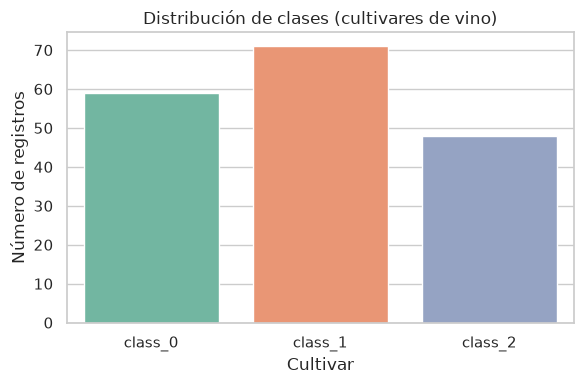

In [6]:
conteo_clases = wine_df['target_name'].value_counts()
print(conteo_clases)
print()
print((conteo_clases/len(wine_df)*100).round(2).astype(str) + ' %')

plt.figure(figsize=(6,4))
sns.countplot(data=wine_df, x='target_name', hue='target_name',palette='Set2')
plt.title('Distribución de clases (cultivares de vino)')
plt.xlabel('Cultivar')
plt.ylabel('Número de registros')
plt.tight_layout()
plt.show()

**Observación:**

Las tres clases están razonablemente balanceadas (ninguna representa menos del 27% ni más del 40% del total), por lo que no es necesario aplicar técnicas de balanceo (como sobremuestreo o submuestreo) para el modelo baseline, y una métrica como *accuracy* podría ser bastante informativa (aunque de cualquier forma se tomara en cuenta *precision*, *recall* y *f1*).

**3. Histogramas.** 

Se genera un histograma con curva KDE para cada variable numérica, para observar la forma de su distribución.

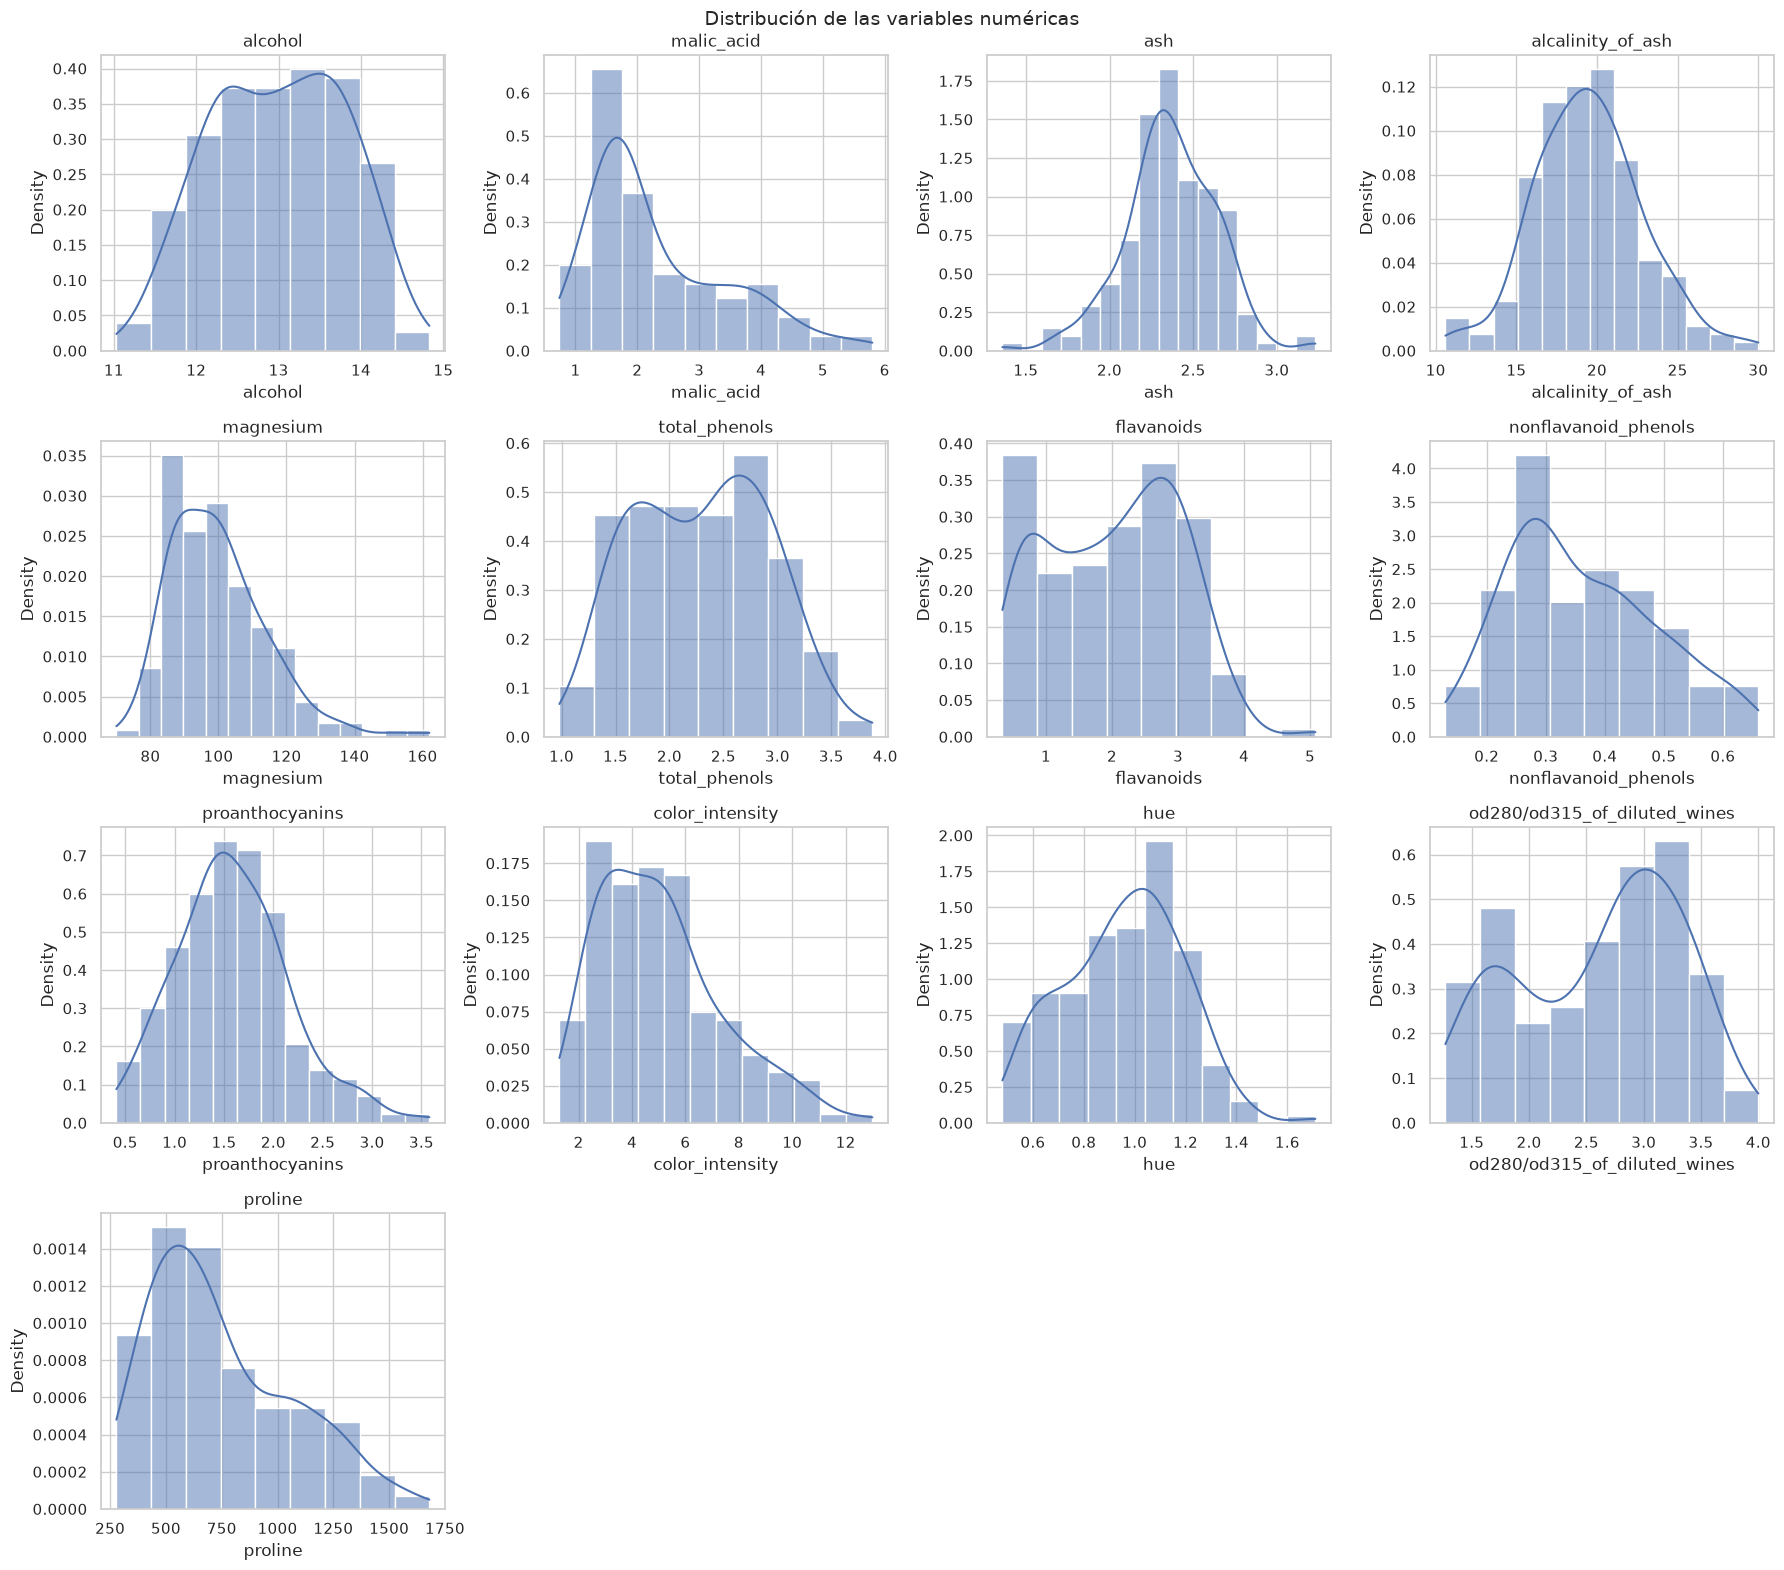

In [7]:
fig, axes = plt.subplots(4, 4,figsize=(18,16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=wine_df, x=col,kde=True,stat='density', ax=axes[i])
    axes[i].set_title(col)


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribución de las variables numéricas',fontsize=14)
plt.tight_layout()
plt.show()

**Observación:** 

Con estos histogramas se observa que variables como `proline`, `malic_acid`, `color_intensity` y `magnesium` presentan una asimetría positiva (cola hacia la derecha), consistente con sus valores de skewness positivos.

Los demás variables muestran una distribución simétrica.

**4. Boxplots por variable.** 

De igual manera se hace un análsis con Boxplot para comparar visualmente con la mediana y detectar posibles outliers.

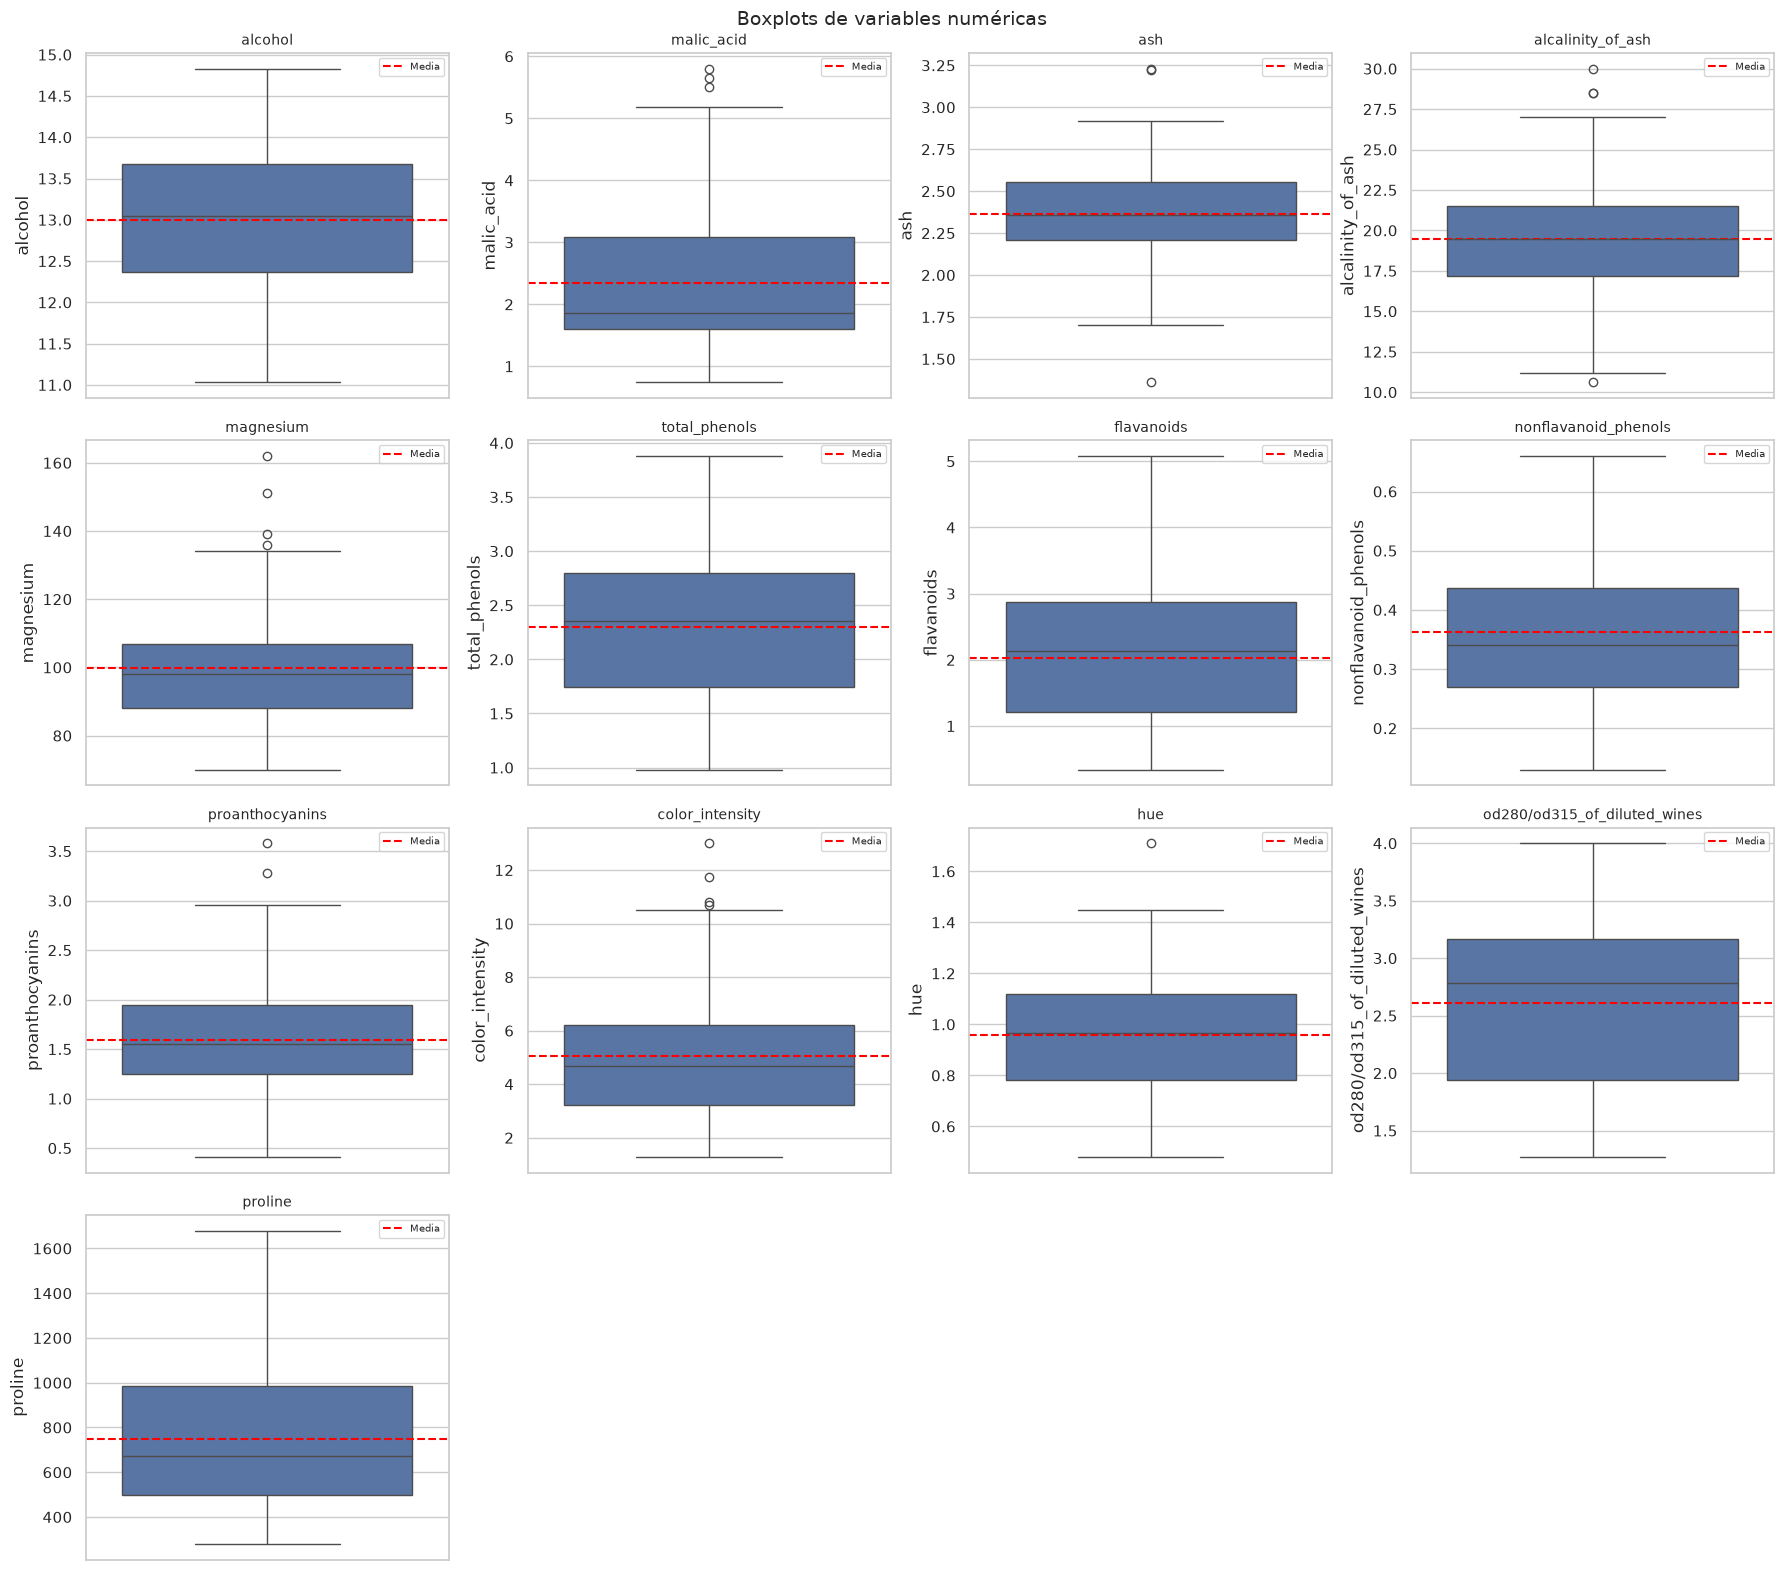

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=wine_df[col], ax=axes[i])
    media = wine_df[col].mean()
    axes[i].axhline(media, color='red', linestyle='--',linewidth=1.5, label='Media')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots de variables numéricas',fontsize=14)
plt.tight_layout()
plt.show()

**Observación:**

Se aprecia que algunas variables como `malic_acid` y `color_intensity` presentan mayor variabilidad y outliers, mientras que otras como `alcohol` y `flavanoids` tienen distribuciones más compactas en la media. 

**5. Matriz de correlación (Pearson).** 

Después se realiza una matriz de correlación para cuantificar estas relaciones lineales entre las variables numéricas.

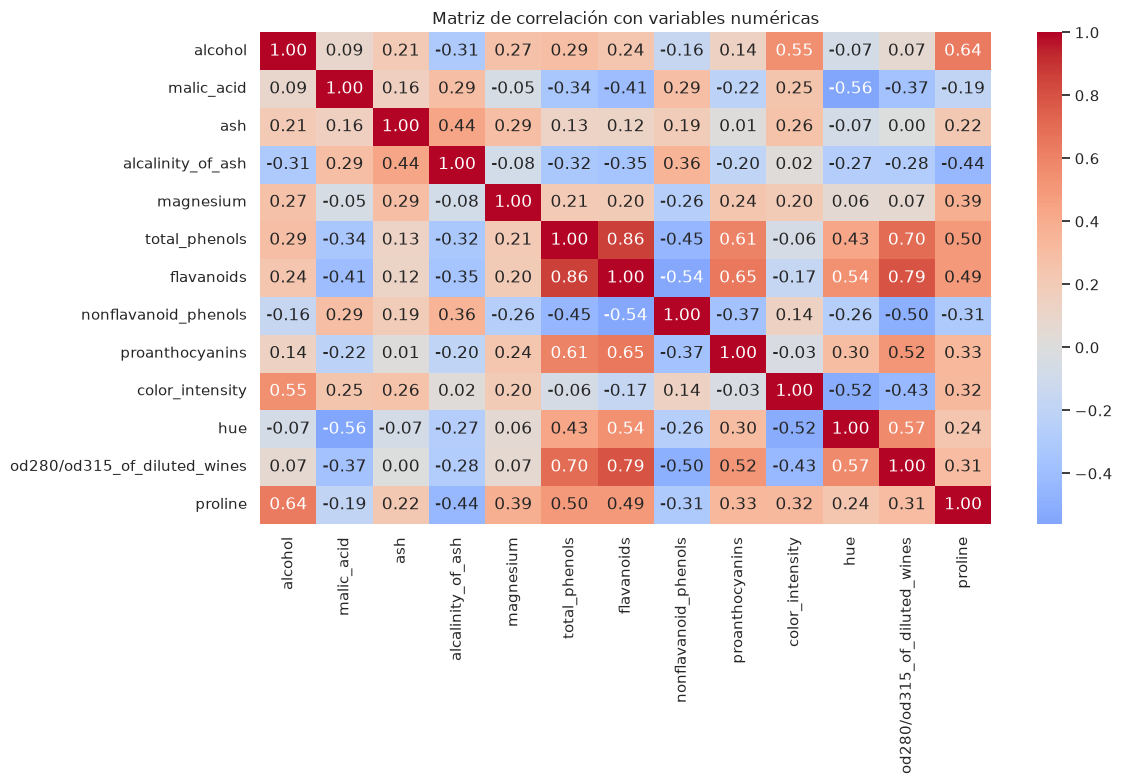

In [9]:
plt.figure(figsize=(12, 8))
corr = wine_df[num_cols].corr(numeric_only=True)
sns.heatmap(round(corr, 2), annot=True, fmt='.2f',cmap='coolwarm', center=0)
plt.title('Matriz de correlación con variables numéricas')
plt.tight_layout()
plt.show()

**Observación:** 

Con esta matriz de correlación se puede observar como las variables`total_phenols` y `flavanoids` están fuertemente correlacionadas (r ≈ 0.86), lo cual es esperable ya que los flavonoides son un subtipo de fenoles. También se observa una correlación alta entre `flavanoids` y `od280/od315_of_diluted_wines` (r ≈ 0.79), y puede indicar que ambas variables aportan información similar sobre la composición del vino.

**6. Matriz de dispersión**

Finalmente se seleccionaron las variables `flavanoids`, `proline`, `color_intensity` y `alcohol` para la matriz de dispersión, ya que al analizar los boxplots y la matriz de correlación, son las que muestran mayor variabilidad entre clases y mejor capacidad discriminante.

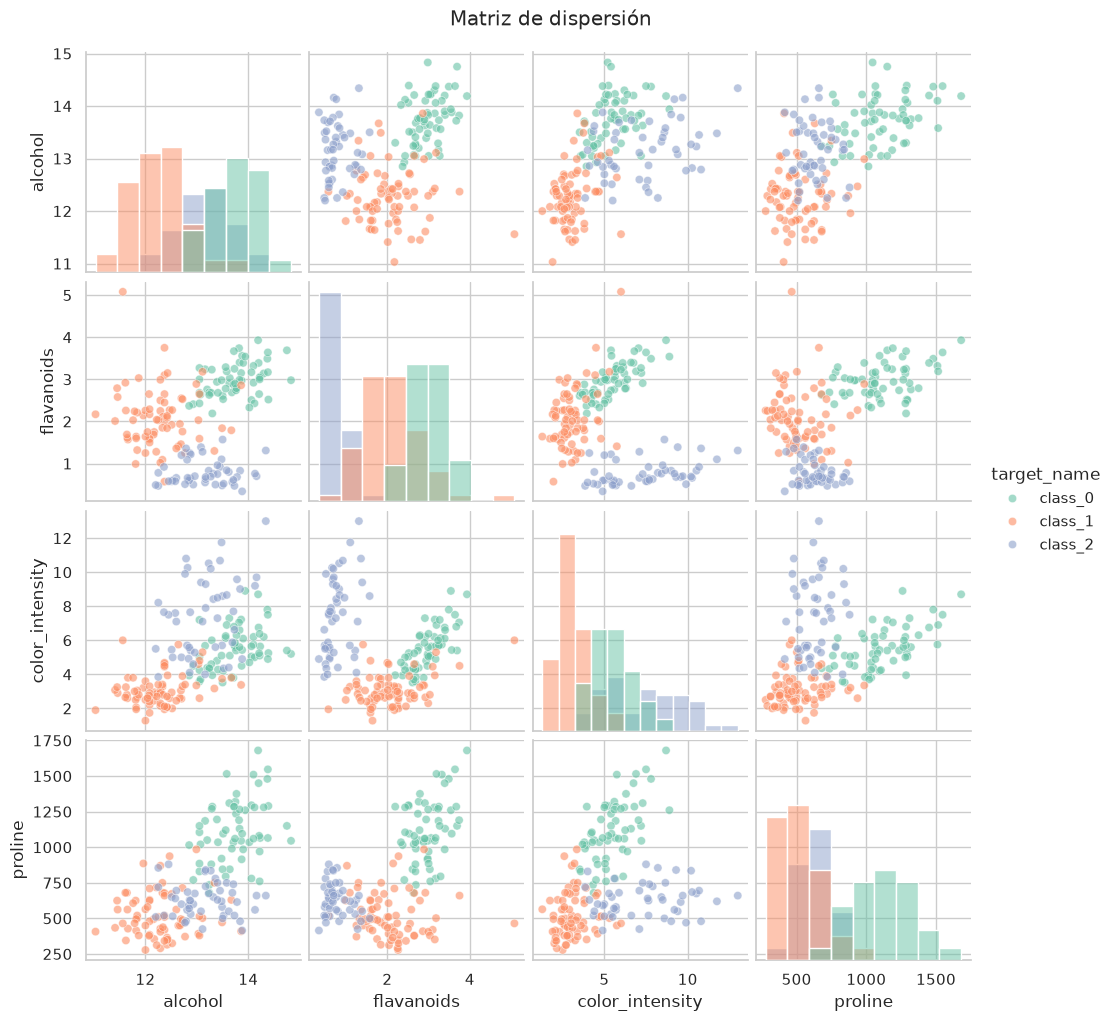

In [10]:
varss= ['alcohol', 'flavanoids','color_intensity','proline']

sns.pairplot(wine_df[varss + ['target_name']], hue='target_name',
             palette='Set2', diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Matriz de dispersión', y=1.02)
plt.show()

Se observa que `flavanoids` es la variable con una alta capacidad para diferenciar entre las clases, tanto con la variable `alcohol` como con `color_intensity` y `proline`, las tres clases forman grupos bastante diferenciados, de igual manera, la variable `color_intensity` complementa bien esta separación, ya que se puede ver como `class_2` se distingue por combinar una intensidad de color alta con flavonoides bajos y `class_0` para flavonoides altos. 

En conjunto, estas variables muestran una buena capacidad para separar a los tres cultivos, lo que es buena señal de que un modelo de clasificación relativamente simple debería poder distinguirlos con buen desempeño.

# Paso 3: Limpia de datos

Para esta seccion se verifica lo siguiente: valores faltantes, registros duplicados, outliers y tipos de datos incorrectos.

**1. Valores faltantes.**

In [11]:
nulos = wine_df.isnull().sum()
print(nulos)
print()
print(f"Total de valores faltantes en el dataset: {nulos.sum()}")

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0
dtype: int64

Total de valores faltantes en el dataset: 0


**Observación:** El dataset "Wine" no tiene valores faltantes, por lo que no se requiere hacer ninguna acción de imputación o eliminación por este concepto.

**2. Registros duplicados.**

In [12]:
registros_iniciales = len(wine_df)
duplicados = wine_df.duplicated().sum()
print(f"Registros iniciales:{registros_iniciales}")
print(f"Registros duplicados encontrados:{duplicados}")

wine_df = wine_df.drop_duplicates().reset_index(drop=True)
print(f"Registros después de eliminar duplicados: {len(wine_df)}")

Registros iniciales:178
Registros duplicados encontrados:0
Registros después de eliminar duplicados: 178


**Observación:** De igual manera, no se encontraron registros duplicados, por lo que no se eliminó ningún renglón en este paso (Pero en este caso se deja el `drop_duplicates()` para temas de reproducibilidad).

**3. Tipos de datos incorrectos.**

In [13]:
print(wine_df.dtypes)

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
target_name                         str
dtype: object


**Observación:** 

Se puede observar como todas las 13 variables predictoras son numéricas continuas (`float64`). Por otra parte, la columna `target` es un entero (0/1/2) que representa una categoría nominal, no una cantidad, así que se puede convertir a tipo `category` para dejar claro su rol estadístico y evitar que se trate como variable numérica continua en análisis futuros.

In [14]:
wine_df['target'] = wine_df['target'].astype('category')
wine_df['target_name'] = wine_df['target_name'].astype('category')
print(wine_df.dtypes[['target','target_name']])

target         category
target_name    category
dtype: object


**4. Outliers.**

In [15]:
def resumen_outliers_iqr(df,columnas):
    resumen = []
    for col in columnas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3-q1
        lim_inf = q1-1.5*iqr
        lim_sup =q3 + 1.5 *iqr
        n_outliers = ((df[col]<lim_inf) | (df[col]>lim_sup)).sum()
        resumen.append({
            'variable': col,
            'lim_inferior': round(lim_inf,2),
            'lim_superior': round(lim_sup,2),
            'n_outliers': n_outliers,
            'pct_outliers': round(100*n_outliers /len(df),2)
        })
    return pd.DataFrame(resumen).sort_values('n_outliers', ascending=False)

resumen_outliers = resumen_outliers_iqr(wine_df, num_cols)
resumen_outliers

,variable,lim_inferior,lim_superior,n_outliers,pct_outliers
4,magnesium,59.50,135.50,4,2.25
3,alcalinity_of_ash,10.75,27.95,4,2.25
9,color_intensity,-1.25,10.67,4,2.25
1,malic_acid,-0.62,5.30,3,1.69
2,ash,1.69,3.08,3,1.69
8,proanthocyanins,0.20,3.00,2,1.12
10,hue,0.28,1.63,1,0.56
0,alcohol,10.39,15.65,0,0.00
5,total_phenols,0.16,4.39,0,0.00
7,nonflavanoid_phenols,0.02,0.69,0,0.00


**Observación:** 

Después de analizar los outliers usando el criterio de rango intercuartílico, algunas variables como `magnesium`, `alcalinity_of_ash` o `color_intensity` presentan un pequeño número de valores atípicos (4 registros), lo cual es menor a un 3%. 
Por lo que se decidió no eliminar los registros, porque:

1. Son mediciones fisicoquímicas de vinos reales, no errores de captura (a diferencia, por ejemplo, de una edad negativa o un porcentaje mayor a 100%).
2. El dataset ya es pequeño (178 registros); eliminar más filas reduciría aún más el tamaño de entrenamiento.

Suponiendo que se encuentran valores imposibles (por ejemplo, `alcohol` negativo o `hue` fuera de un rango posible), sí se habrían eliminado.

In [16]:
registros_finales = len(wine_df)
print(f"Registros iniciales: {registros_iniciales}")
print(f"Registros finales tras limpieza: {registros_finales}")
print(f"Registros eliminados: {registros_iniciales - registros_finales} "
      f"({100*(registros_iniciales - registros_finales)/registros_iniciales:.2f}% del total)")

Registros iniciales: 178
Registros finales tras limpieza: 178
Registros eliminados: 0 (0.00% del total)


# Paso 4: Entrenamiento de un modelo base

**1. Partición entrenamiento/prueba.** 

Primero se realiza una partición 80/20, estratificada por la variable objetivo para preservar la proporción de clases en ambos conjuntos.

In [17]:
X = wine_df[num_cols]
y = wine_df['target'].astype(int)

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.20, random_state=42,stratify=y)

print(f"Xtrain: {Xtrain.shape}, Xtest: {Xtest.shape}")
print()

print("Distribución de clases en train (%):")
print((ytrain.value_counts(normalize=True)*100).round(1))
print()
print("Distribución de clases en test(%):")
print((ytest.value_counts(normalize=True)* 100).round(1))

Xtrain: (142, 13), Xtest: (36, 13)

Distribución de clases en train (%):
target
1    40.1
0    33.1
2    26.8
Name: proportion, dtype: float64

Distribución de clases en test(%):
target
1    38.9
0    33.3
2    27.8
Name: proportion, dtype: float64


**2. Modelo baseline**

En este paso es donde se elige el baseline con el que se tiene que trabajar y superar con el modelo que se proponga como solución.

In [18]:
modelo_baseline = DummyClassifier(strategy='most_frequent', random_state=42)
modelo_baseline.fit(Xtrain, ytrain)

acc_baseline_train=modelo_baseline.score(Xtrain, ytrain)
acc_baseline_test= modelo_baseline.score(Xtest, ytest)

print(f"Accuracy del baseline (train): {acc_baseline_train:.4f}")
print(f"Accuracy del baseline (test): {acc_baseline_test:.4f}")

Accuracy del baseline (train): 0.4014
Accuracy del baseline (test): 0.3889


Como punto de referencia, se entrena un `DummyClassifier` con estrategia `most_frequent`. Y esa métrica o desempeño establece el piso (baseline) que cualquier modelo real debe superar claramente para justificar su uso. 

**3. Pruebas con diferentes modelos.** 

En esta parte se prueban diferentes modelos y su desempeño con el dataset.

In [19]:
rs = 42

prueba_modelos = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=rs))
    ]),
    'kNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'SVC': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', C=10.0, random_state=rs))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=rs))
    ])}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)
puntajess = ['accuracy', 'f1_weighted']

resultados = {}
for nombre, pipe in prueba_modelos.items():
    scores = cross_validate(pipe, Xtrain, ytrain, cv=cv, scoring=puntajess,
                             return_train_score=True)
    resultados[nombre] = scores
    print(f"{nombre:20s} | test accuracy: {scores['test_accuracy'].mean():.4f} "
          f"test f1_weighted: {scores['test_f1_weighted'].mean():.4f}")


LogisticRegression   | test accuracy: 0.9791 test f1_weighted: 0.9788
kNN                  | test accuracy: 0.9507 test f1_weighted: 0.9508
SVC                  | test accuracy: 0.9931 test f1_weighted: 0.9932
RandomForest         | test accuracy: 0.9791 test f1_weighted: 0.9793


In [20]:
brechas = []
for nombre, res in resultados.items():
    train_mean = res['train_accuracy'].mean()
    test_mean = res['test_accuracy'].mean()
    brechas.append({
        'modelo': nombre,
        'train_accuracy': round(train_mean, 4),
        'test_accuracy': round(test_mean, 4),
        'brecha': round(train_mean-test_mean, 4)
    })

pd.DataFrame(brechas).sort_values('test_accuracy', ascending=False)

,modelo,train_accuracy,test_accuracy,brecha
2,SVC,1.0000,0.9931,0.0069
0,LogisticRegression,1.0000,0.9791,0.0209
3,RandomForest,1.0000,0.9791,0.0209
1,kNN,0.9771,0.9507,0.0264


**5. Selección del modelo.**

Modelo elegido: SVC (kernel RBF).

De los cinco modelos evaluados el SVC obtuvo el mejor desempeño promedio (accuracy = 0.9931, f1_score = 0.9932), con la menor desviación estándar (0.0138) y la brecha train-test más pequeña (0.0069), lo que indica que generaliza bien sin memorizar el conjunto de entrenamiento. 

De igual manera se verificó que este resultado no dependía de una partición particular, ya que al repetir la validación cruzada con semillas distintas, el orden de los modelos se mantuvo en este umbral aceptable, por ello, se elige el SVC como modelo final.

**6. Entrenamiento del modelo baseline.**

In [21]:
pipeline_baseline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', SVC(
        C=1.0,
        kernel='rbf',
        gamma='scale',
        random_state=rs
    ))])

pipeline_baseline.fit(Xtrain, ytrain)
pipeline_baseline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['alcohol','malic_acid','ash',...,'hue','od280/od315_of_diluted_wines', 'proline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


# Paso 5: Evaluación del modelo

**1. Predicciones y métricas de desempeño sobre el conjunto de prueba.**

In [22]:
y_pred = pipeline_baseline.predict(Xtest)

acc = accuracy_score(ytest, y_pred)
prec_sc = precision_score(ytest, y_pred, average='weighted')
rec_sc = recall_score(ytest, y_pred, average='weighted')
fr_sc = f1_score(ytest, y_pred, average='weighted')

print(f"Accuracy:        {acc:.4f}")
print(f"Precision:   {prec_sc:.4f}")
print(f"Recall:      {rec_sc:.4f}")
print(f"F1-score:    {fr_sc:.4f}")
print()



print("Resumen completo:")
print(classification_report(ytest, y_pred, target_names=vinos.target_names))

Accuracy:        0.9722
Precision:   0.9741
Recall:      0.9722
F1-score:    0.9720

Resumen completo:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



**2. Matriz de confusión.**

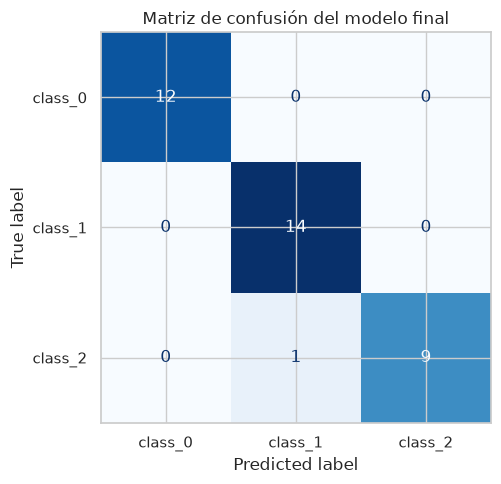

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(ytest, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=vinos.target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de confusión del modelo final')
plt.tight_layout()
plt.savefig('confusion_matriz.png',dpi=150, bbox_inches='tight')
plt.show()

**3. Validación cruzada.**

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)
cv_scores = cross_val_score(pipeline_baseline, X, y, cv=cv, scoring='accuracy')

print(f"Accuracy por fold: {np.round(cv_scores,4)}")
print(f"Accuracy promedio (5-fold CV): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Accuracy por fold: [0.9444 1.     0.9722 1.     1.    ]
Accuracy promedio (5-fold CV): 0.9833 +/- 0.0222


**4. Interpretación de los resultados.**

- El modelo final (SVC) fue seleccionado tras comparar cinco algoritmos diferentes mediante validación cruzada, donde SVC mostró el mejor desempeño y una brecha train-test más pequeña y consistente con diferentes semillas, esto comprueba de que generaliza bien y no memoriza el conjunto de entrenamiento.
- La matriz de confusión muestra en qué clases se concentran los errores, consistente con lo mostrado en el pairplot del EDA entre cultivares con valores similares de flavonoides y color.
- El modelo final (SVC) alcanzó ~0.99 de accuracy, superando al baseline que se tenía de 0.4014, lo que evidencia que el modelo captura relaciones reales entre las propiedades fisicoquímicas y el cultivar del vino, y no solo la distribución de clases.

# Paso 6: Registro del experimento en MLflow

Se usa MLflow Tracking para registrar de forma reproducible: los parámetros del modelo baseline, las métricas de desempeño obtenidas en el Paso 5, y el propio modelo junto con la matriz de confusión.

In [25]:
mlflow.set_experiment("clasificación_vinos")

with mlflow.start_run(run_name="modelo_final_svc") as run:

    # Parámetros
    mlflow.log_param("modelo_final", "SVC")
    mlflow.log_param("kernel","rbf")
    mlflow.log_param("C", 1.0)
    mlflow.log_param("gamma","scale")
    mlflow.log_param("scaler","StandardScaler")
    mlflow.log_param("test_size",0.20)
    mlflow.log_param("random_state", rs)
    mlflow.log_param("cv_folds", 5)

    # Métricas
    mlflow.log_metric("accuracy_test",acc)
    mlflow.log_metric("precision_weighted_test", prec_sc)
    mlflow.log_metric("recall_weighted_test", rec_sc)
    mlflow.log_metric("f1_weighted_test", fr_sc)

    # Métricas (validación cruzada)
    mlflow.log_metric("accuracy_cv_mean", cv_scores.mean())
    mlflow.log_metric("accuracy_cv_std", cv_scores.std())

    #Métricas del baseline
    mlflow.log_metric("accuracy_dummy_baseline_test",acc_baseline_test)

    #Artefactos (Matriz de confusión)
    mlflow.log_artifact("confusion_matriz.png")

    # Modelo final
    mlflow.sklearn.log_model(pipeline_baseline, name="model")

    run_id = run.info.run_id
    print(f"Run registrado en MLflow con run_id: {run_id}")
    print(f"Experimento: wine_classification_baseline")

Run registrado en MLflow con run_id: a0008bdba48b46ffa6173439c3253155
Experimento: wine_classification_baseline


**1. Capturas de pantalla con MLFlow en funcionamiento**

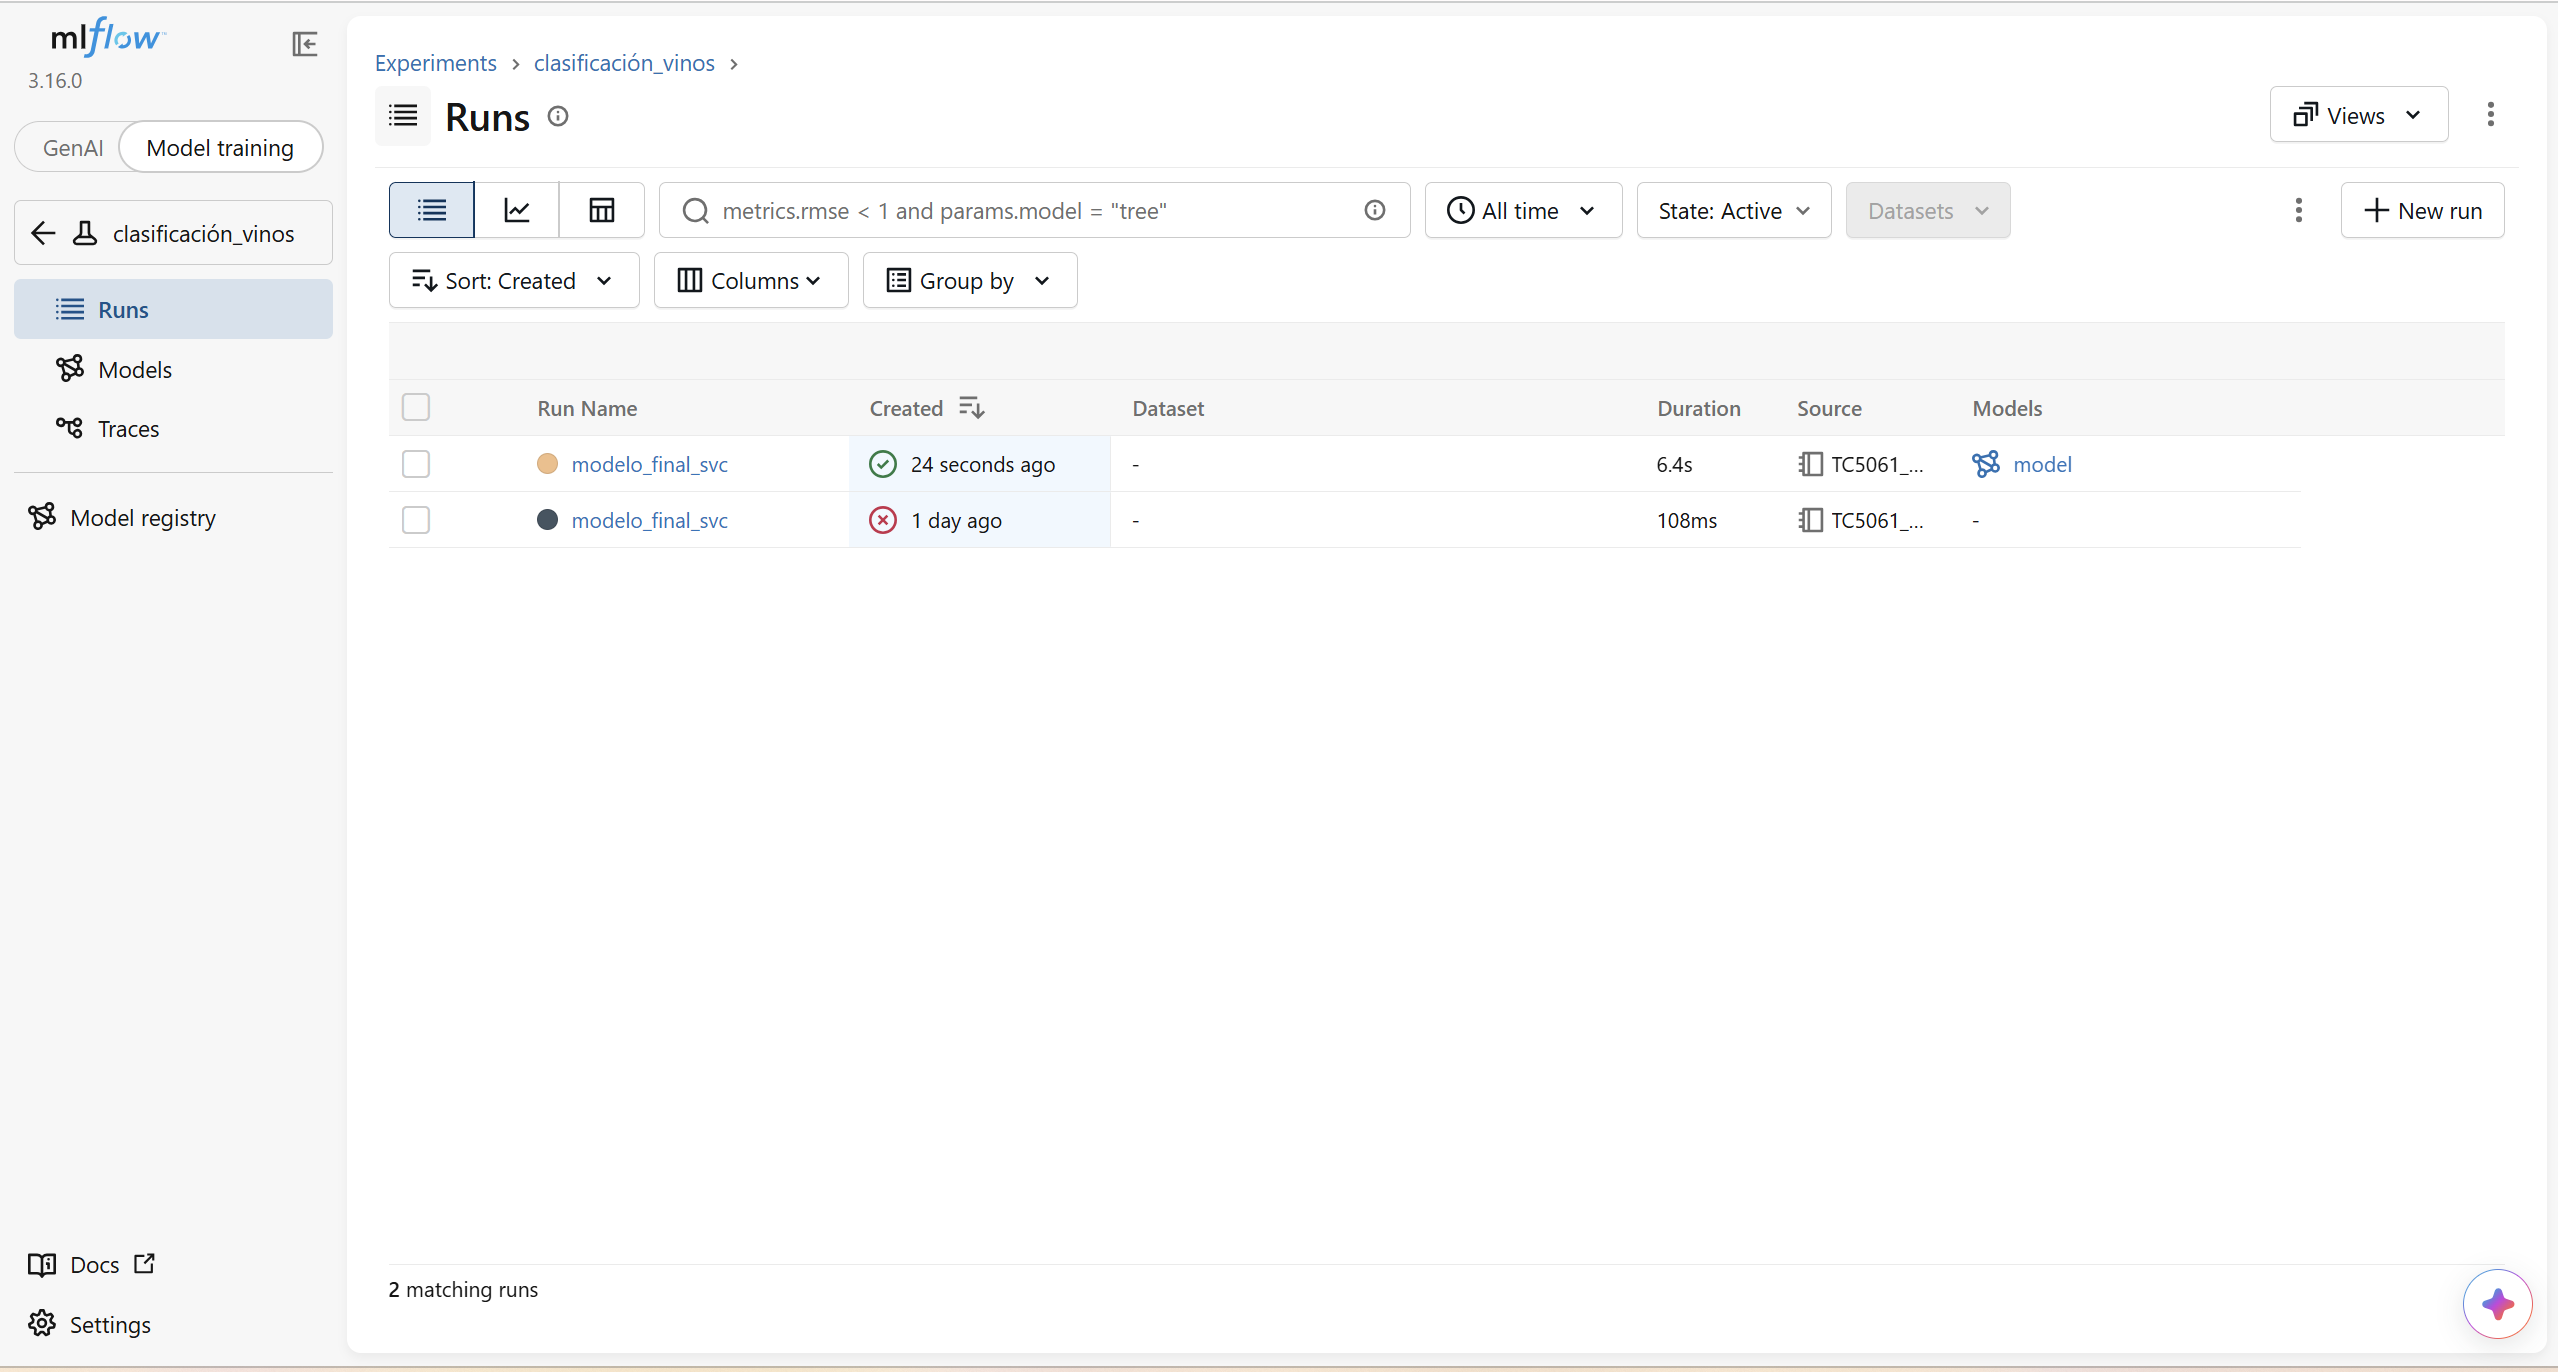

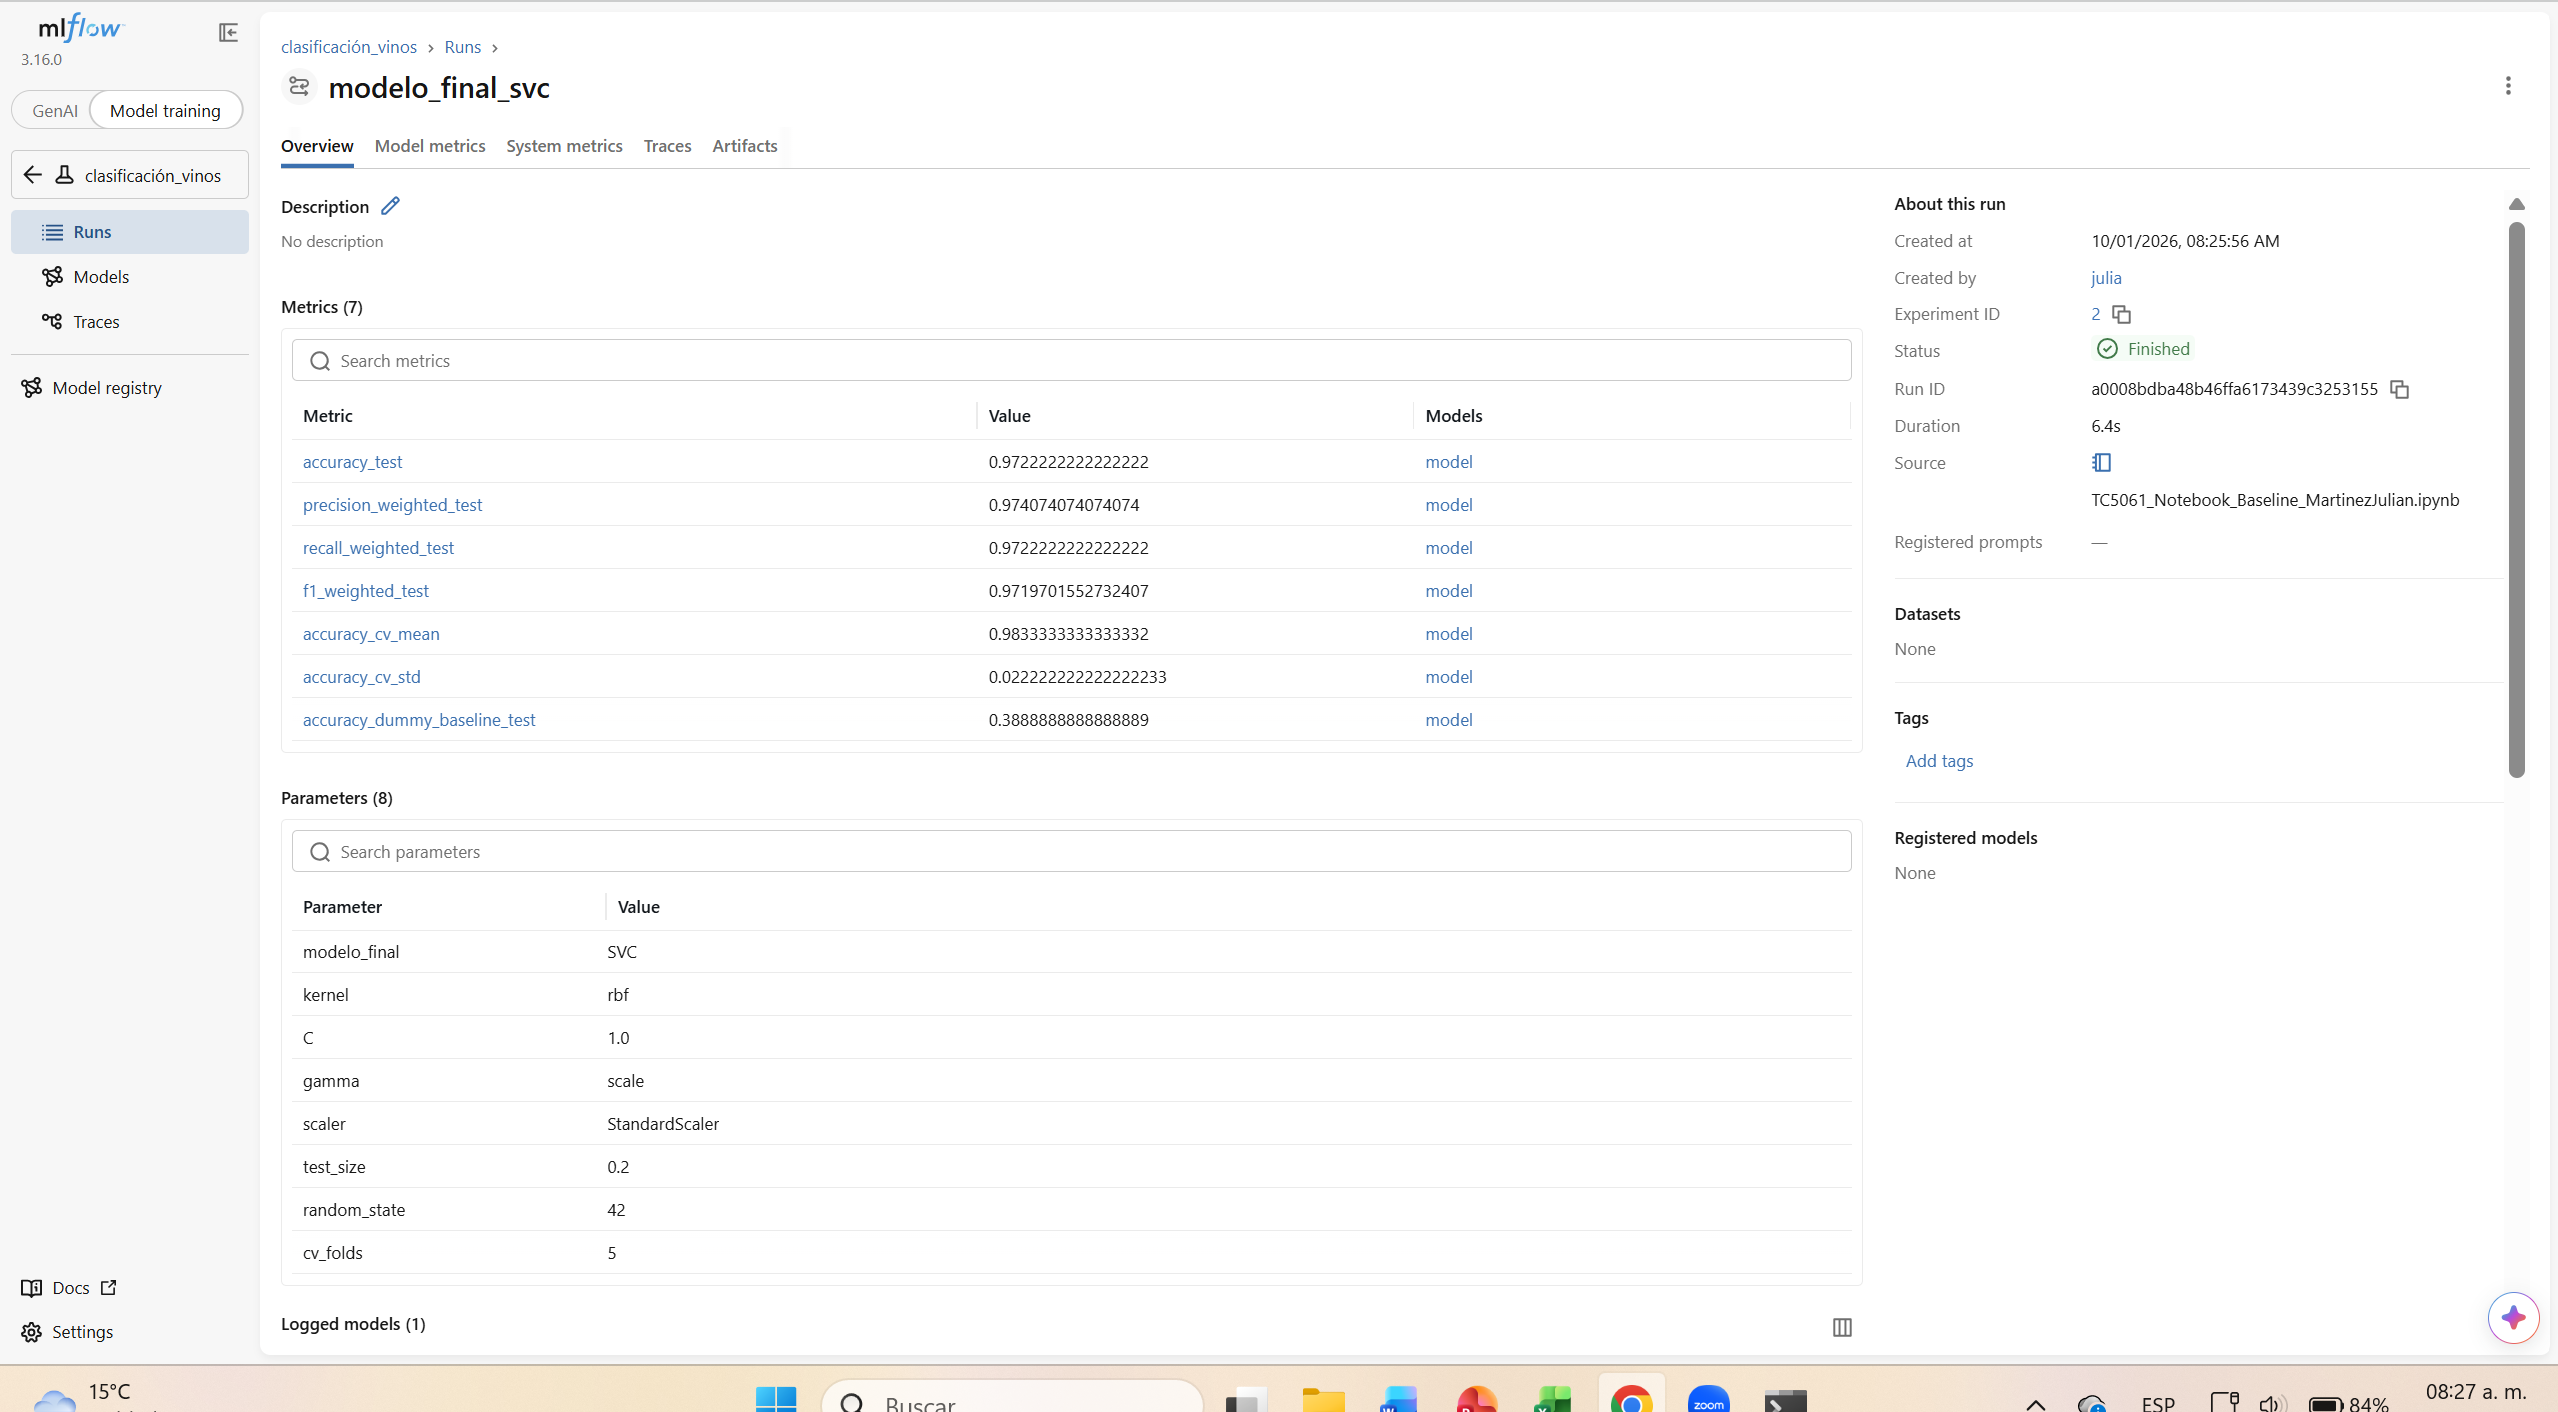

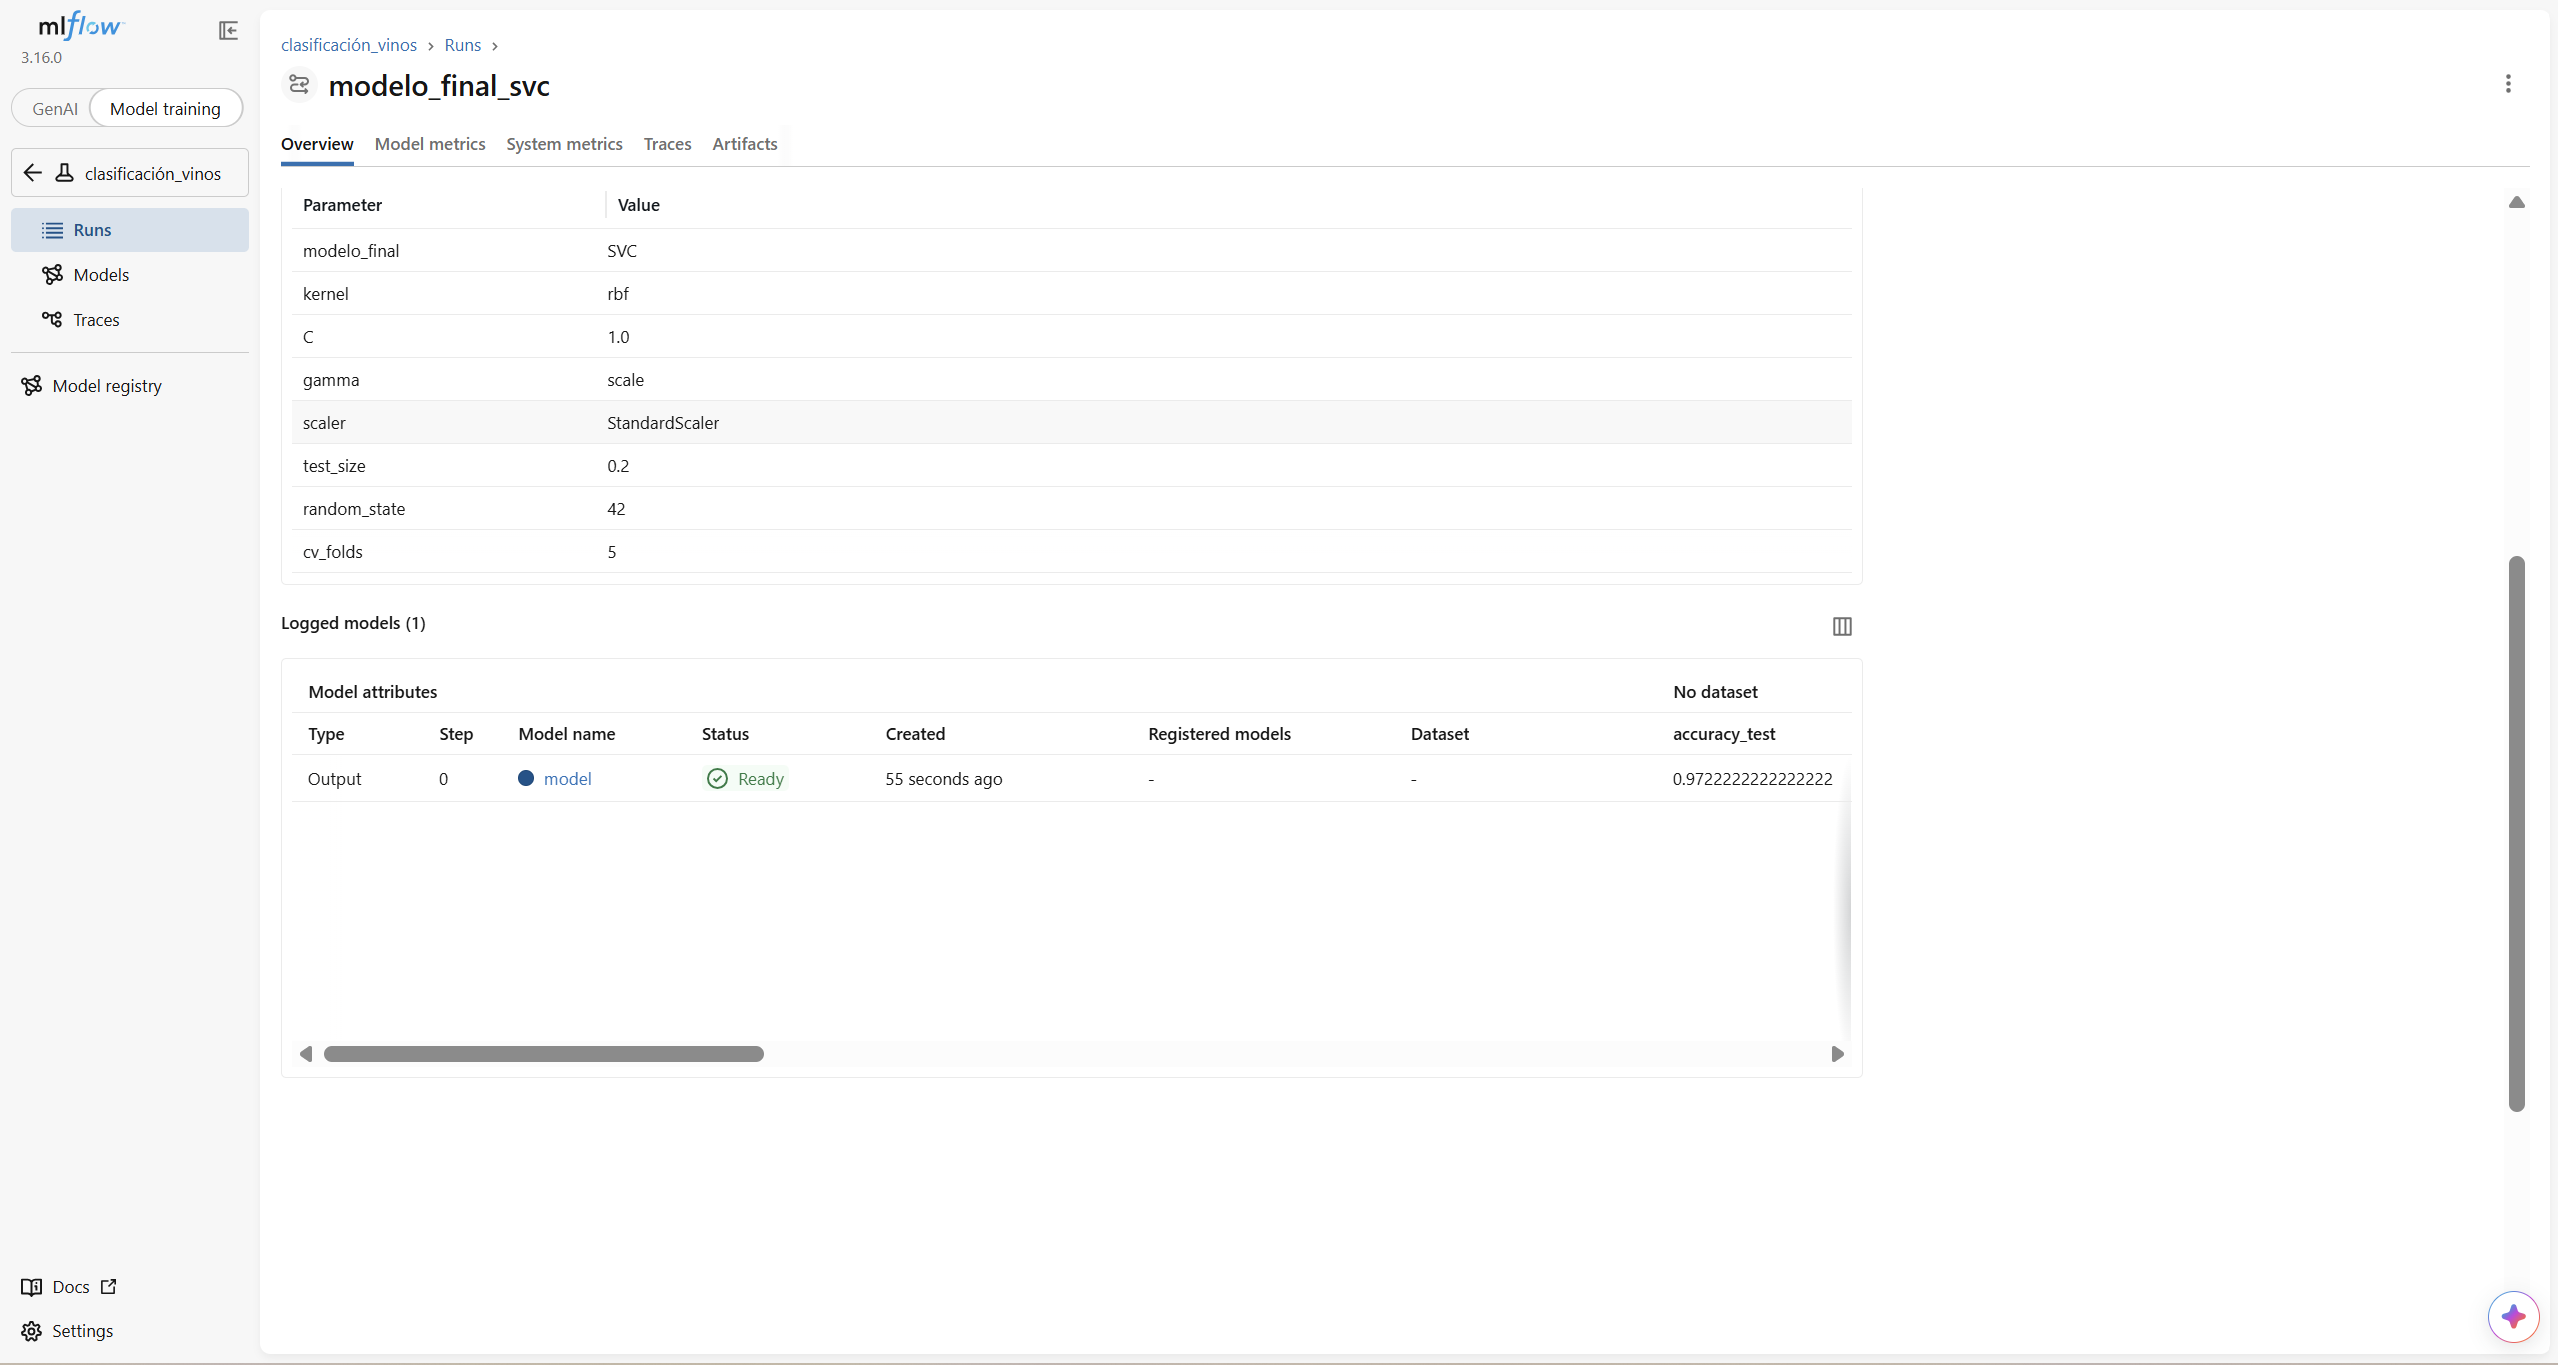

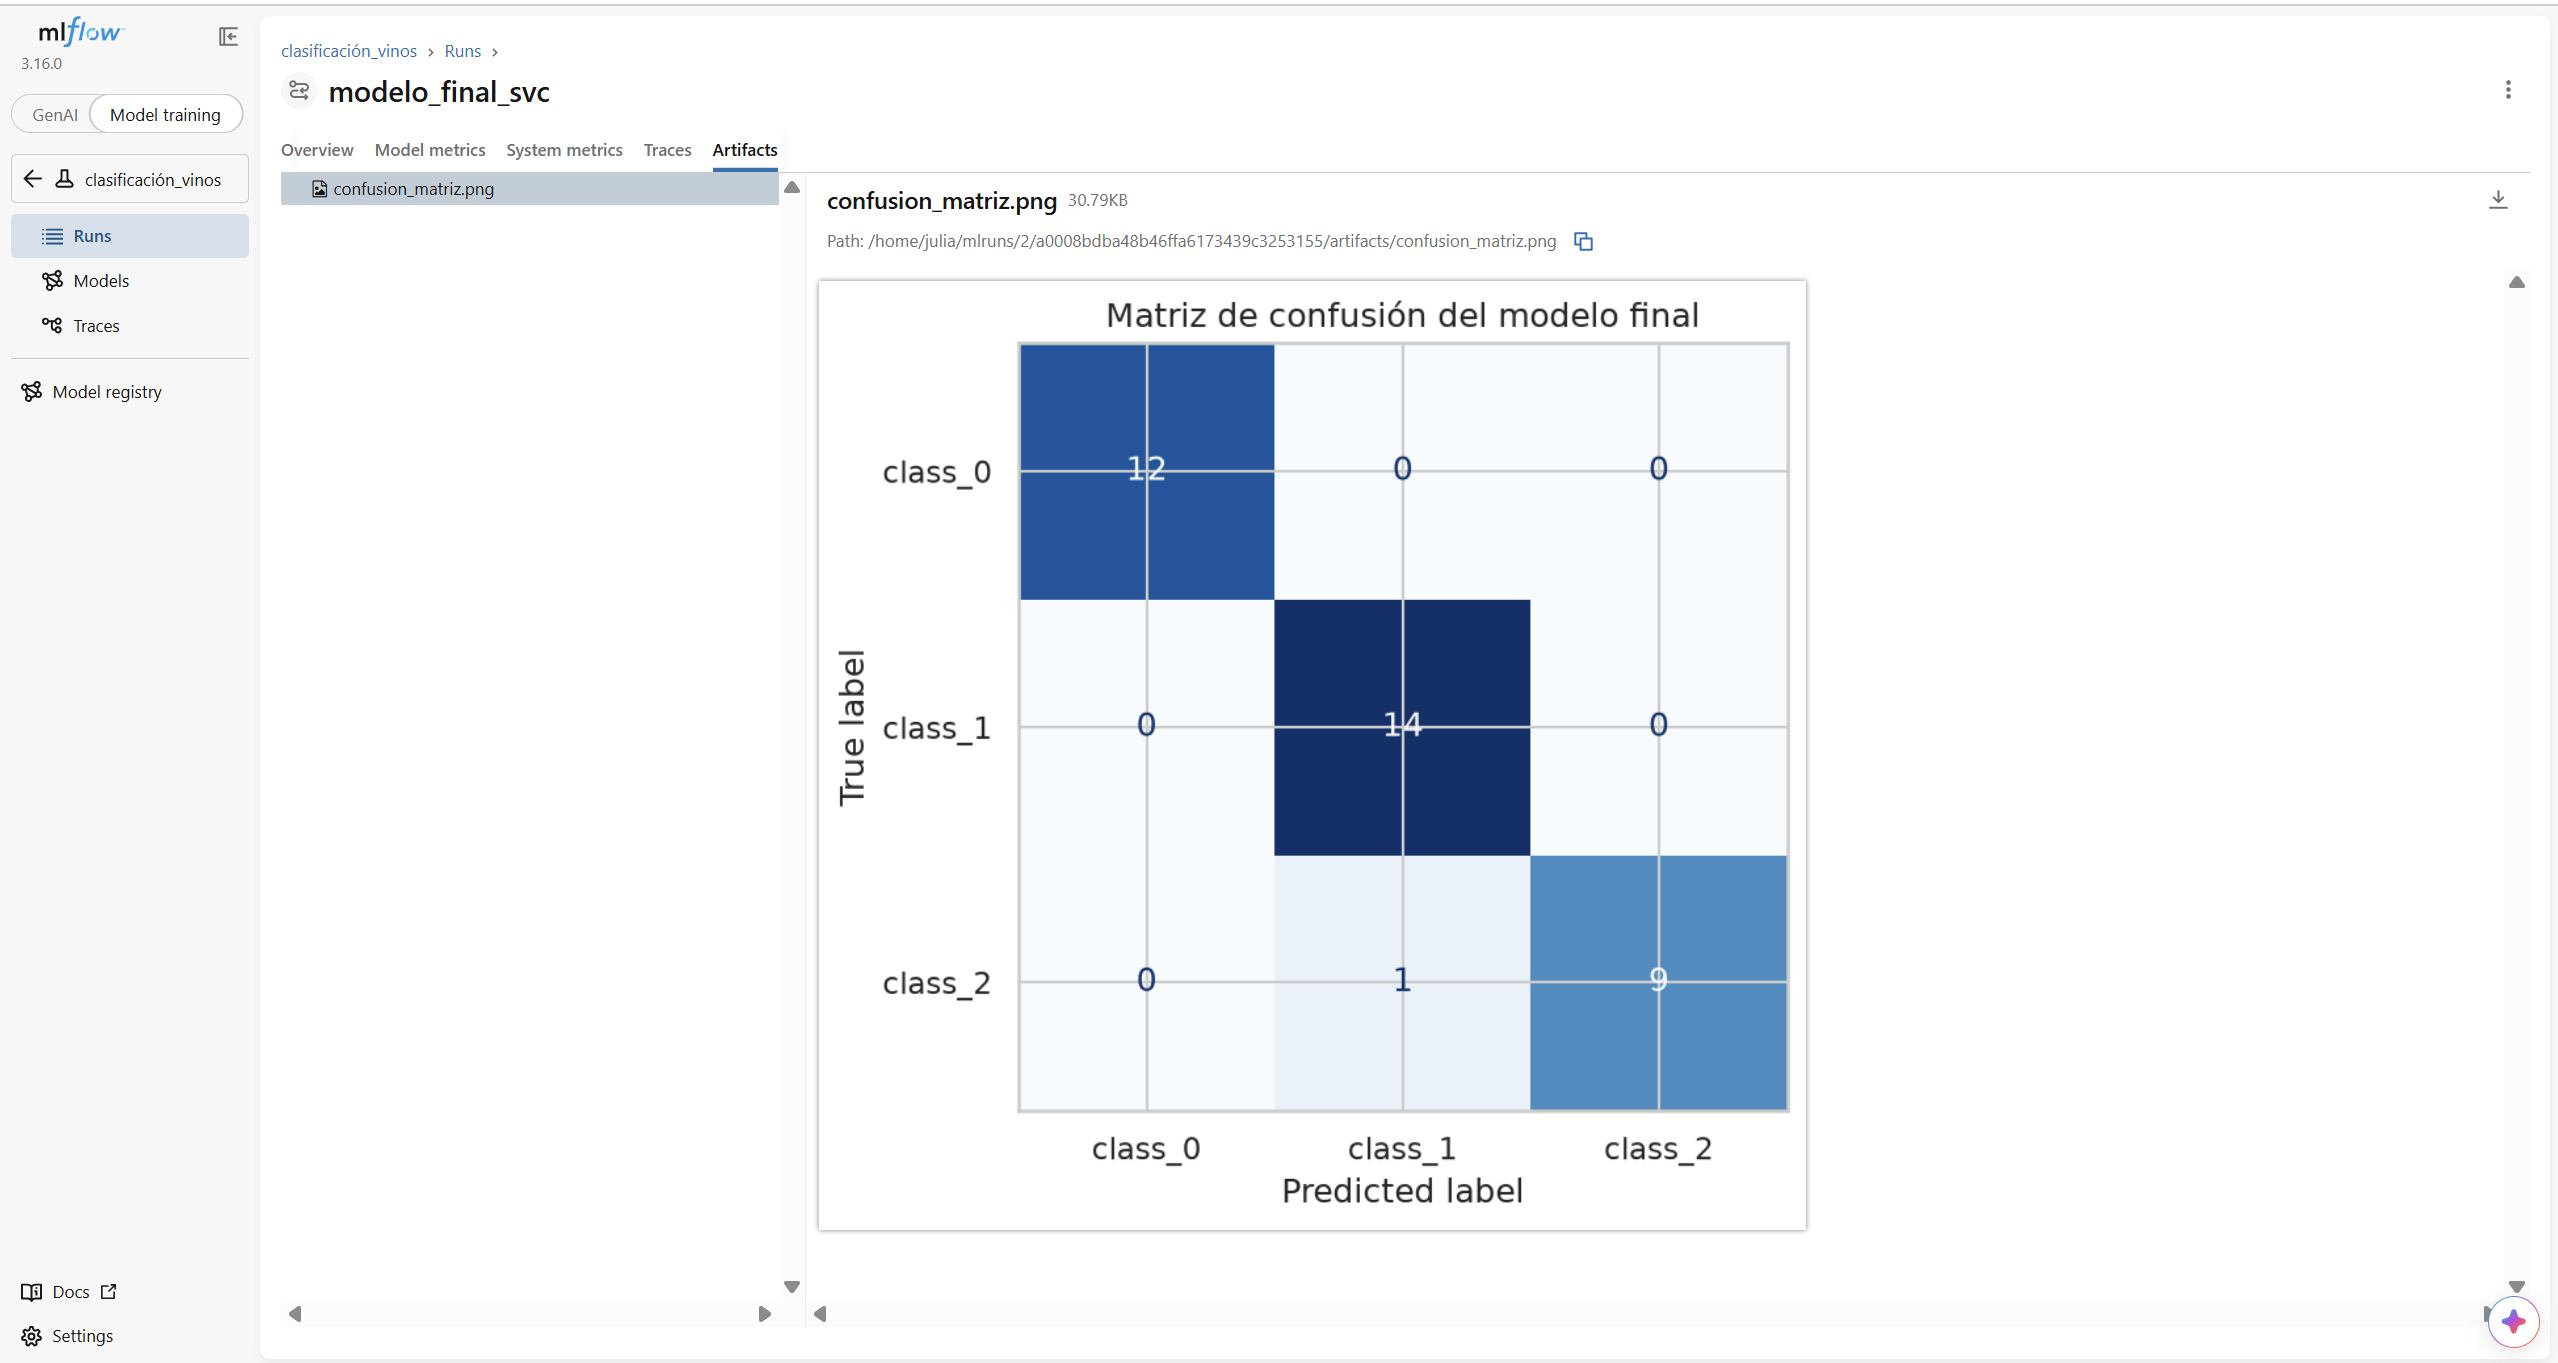

## Conclusiones finales

- El dataset "Wine" resultó ser un caso de estudio limpio (sin datos nulos ni duplicados), pero el flujo completo de limpieza se documentó en esta actividad igualmente, ya que en un proyecto real esta verificación siempre debe hacerse, al igual que verificar su reproducibilidad.
- El EDA permitió identificar qué variables (`flavanoids`, `proline`, `color_intensity` y `alcohol`) separan mejor a los tres cultivares, lo cual se confirmó después con el buen desempeño del modelo final.
- Se estableció un modelo baseline (`DummyClassifier`) con una accuracy de 0.3889 en test, con la proporción de esa clase observada en el EDA. Este sirvio como referencia para cuantificar cuánto valor real aporta el modelo que se use posteriormente.
- Se compararon cuatro modelos candidatos (Logistic Regression, kNN, SVC y Random Forest) mediante validación cruzada estratificada, del cual, el SVC resultó ser el mejor: mejor desempeño promedio, menor desviación estándar entre folds y la brecha train-test más pequeña y un resultado que se mantuvo estable al repetir la validación con semillas distintas.
- El modelo final (SVC) superó al baseline, confirmando que sí captura relaciones reales entre las propiedades del vino y el cultivar, y no solo la distribución de clases.
- Por último, el registrar el experimento en MLflow permite mantener trazabilidad de parámetros, métricas y artefactos de forma reproducible, algo esencial en cualquier proyecto de ML que se piense iterar o llevar a producción.

## Reflexión final:

A lo largo de esta actividad, la parte donde más sentí la diferencia entre hacer un modelo e implementar herramientas de MLOps fue justo en el registro con MLflow. Antes de esa etapa, todo el proceso quedaba solo en la salida de las celdas del notebook: si cerraba y volvía a correr todo, o si alguien más quería revisar por qué elegí el SVC sobre los demás, tendría que confiar en el archivo o en los comentarios que dejé, pero fácilmente se podrian haber sobrescrito resultados anteriores. Al registrar los parámetros, métricas y el modelo en MLflow, ese historial queda guardado de forma ordenada y consultable, incluso si vuelvo a correr el notebook con otros valores, incluso puedo comparar el run actual contra versiones anteriores sin tener que recordar qué cambié. 
Eso es lo que MLOps le agrega a un proceso como el de esta actividad: no cambia el análisis ni el modelo en sí, sino que lo vuelve rastreable y reproducible en el tiempo.

Actualmente no tengo experiencia profesional en MLOps ni en ciencia de datos, pero este ejercicio me deja claro que aunque un modelo pueda mostrar buen desempeño, si no existe un registro ordenado y reproducible del proceso que llevó, la práctica no es profesional ni sostenible, y esa es la disciplina que quiero llevarme a cualquier proyecto de datos que enfrente más adelante.